<a href="https://colab.research.google.com/github/Lavanya-Manila/handwritten-digit-recognizer/blob/main/handwritten_digit_recognizer_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install tensorflow


In [ ]:
from tensorflow.keras.datasets import mnist

(x_train, y_train), (x_test, y_test) = mnist.load_data()

print(x_train.shape)

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
(60000, 28, 28)


In [ ]:
x_train = x_train / 255.0
x_test = x_test / 255.0

x_train = x_train.reshape(-1,28,28,1)
x_test = x_test.reshape(-1,28,28,1)

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D
from tensorflow.keras.layers import MaxPooling2D
from tensorflow.keras.layers import Flatten
from tensorflow.keras.layers import Dense

model = Sequential()

model.add(
    Conv2D(
        32,
        (3,3),
        activation='relu',
        input_shape=(28,28,1)
    )
)

model.add(MaxPooling2D((2,2)))

model.add(
    Conv2D(
        64,
        (3,3),
        activation='relu'
    )
)

model.add(MaxPooling2D((2,2)))

model.add(Flatten())

model.add(Dense(128, activation='relu'))

model.add(Dense(10, activation='softmax'))

In [ ]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [ ]:
history = model.fit(
    x_train,
    y_train,
    epochs=5,
    validation_data=(x_test,y_test)
)

Epoch 1/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 55s 29ms/step - accuracy: 0.9757 - loss: 0.0819 - val_accuracy: 0.9853 - val_loss: 0.0491
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 80s 28ms/step - accuracy: 0.9868 - loss: 0.0417 - val_accuracy: 0.9873 - val_loss: 0.0354
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 53s 28ms/step - accuracy: 0.9916 - loss: 0.0273 - val_accuracy: 0.9916 - val_loss: 0.0267
Epoch 4/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 83s 29ms/step - accuracy: 0.9936 - loss: 0.0207 - val_accuracy: 0.9902 - val_loss: 0.0316
Epoch 5/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 53s 28ms/step - accuracy: 0.9949 - loss: 0.0155 - val_accuracy: 0.9898 - val_loss: 0.0304


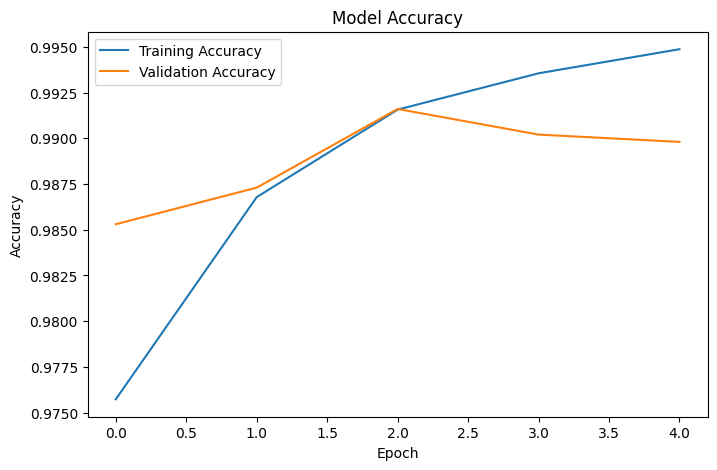

In [ ]:
plt.figure(figsize=(8,5))

plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')

plt.title("Model Accuracy")
plt.xlabel("Epoch") #accuracy graph
plt.ylabel("Accuracy")
plt.legend()

plt.show()

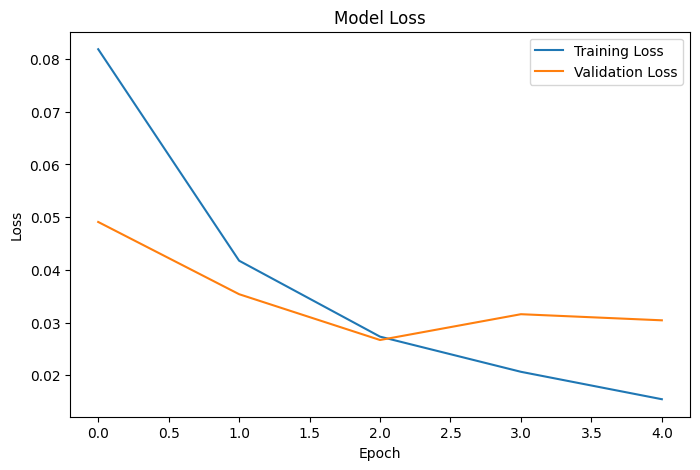

In [ ]:
plt.figure(figsize=(8,5))

plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')

plt.title("Model Loss")#loss graph
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

plt.show()

In [ ]:
loss, accuracy = model.evaluate(x_test,y_test)
print("Accuracy:", accuracy)

313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.9898 - loss: 0.0304
Accuracy: 0.989799976348877


In [ ]:
prediction = model.predict(x_test[:9])

print(prediction.argmax(axis=1))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 112ms/step
[7 2 1 0 4 1 4 9 5]


In [ ]:
prediction = model.predict(x_test)

predicted_labels = prediction.argmax(axis=1)

print(predicted_labels[:10])
print(y_test[:10])

313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step
[7 2 1 0 4 1 4 9 5 9]
[7 2 1 0 4 1 4 9 5 9]


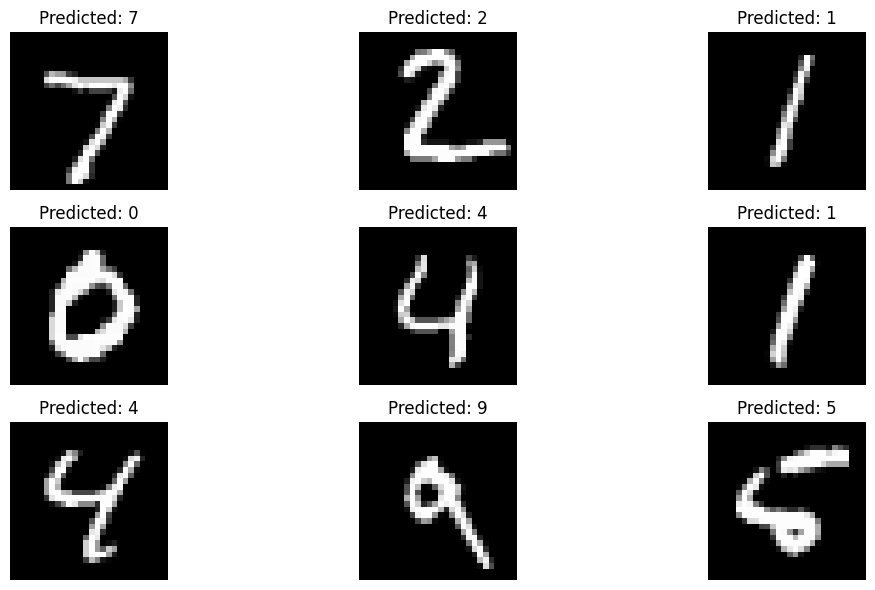

In [ ]:
plt.figure(figsize=(12,6))

for i in range(9):#predition
    plt.subplot(3,3,i+1)
    plt.imshow(x_test[i].reshape(28,28), cmap='gray')
    plt.title(f"Predicted: {predicted_labels[i]}")
    plt.axis('off')

plt.tight_layout()
plt.show()

In [ ]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       204,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 675,104 (2.58 MB)

 Trainable params: 225,034 (879.04 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 450,070 (1.72 MB)

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

<Figure size 800x800 with 0 Axes>

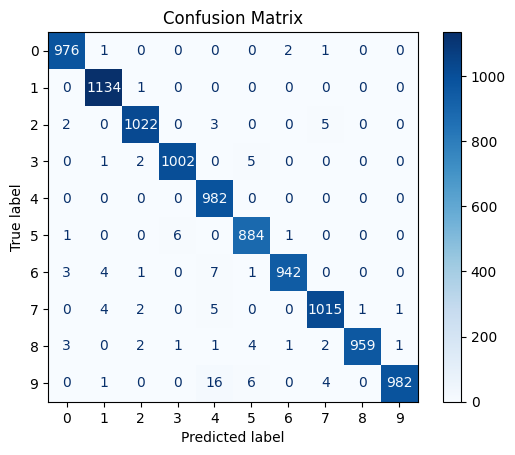

In [ ]:
cm = confusion_matrix(y_test, predicted_labels)
plt.figure(figsize=(8,8))

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=range(10)
)

disp.plot(cmap='Blues')
plt.title("Confusion Matrix")

plt.show()

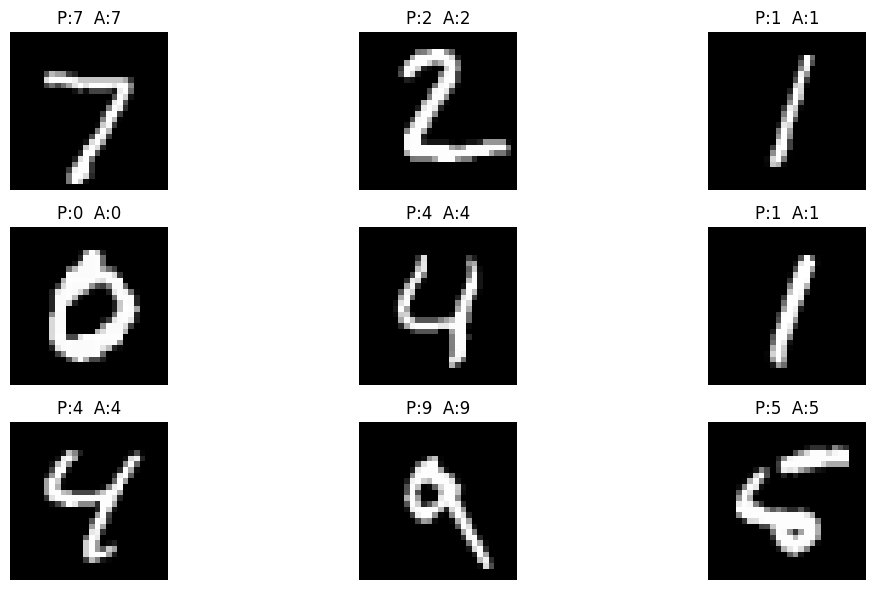

In [ ]:
plt.figure(figsize=(12,6))
#prediction vs actual graph
for i in range(9):
    plt.subplot(3,3,i+1)
    plt.imshow(x_test[i].reshape(28,28), cmap='gray')
    plt.title(f"P:{predicted_labels[i]}  A:{y_test[i]}")
    plt.axis('off')

plt.tight_layout()
plt.show()

In [ ]:
model.save("digit_recognition_model.keras")

Saving four.jpg to four (1).jpg


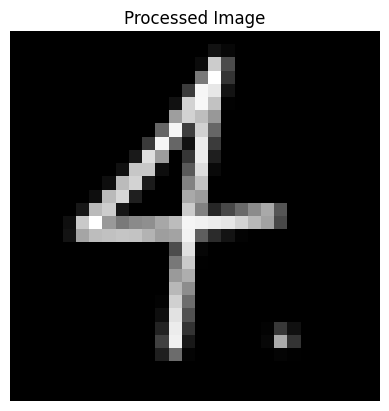

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 98ms/step
Predicted Digit: 4
Confidence: 99.98686 %


In [ ]:
from google.colab import files
from tensorflow.keras.models import load_model
from PIL import Image
import matplotlib.pyplot as plt
import numpy as np

# Upload image
uploaded = files.upload()

filename = list(uploaded.keys())[0]

# Open image
img = Image.open(filename)

# Convert to grayscale
img = img.convert('L')

# Resize
img = img.resize((28,28))

# Convert to NumPy array
img = np.array(img)

# Invert colors (if needed)
img = 255 - img

# Display image
plt.imshow(img, cmap='gray')
plt.title("Processed Image")
plt.axis("off")
plt.show()

# Normalize
img = img / 255.0

# Reshape
img = img.reshape(1,28,28,1)

# Load model
model = load_model("digit_recognition_model.keras")

# Predict
prediction = model.predict(img)

digit = np.argmax(prediction)
confidence = np.max(prediction)

print("Predicted Digit:", digit)
print("Confidence:", confidence*100,"%")